<a href="https://colab.research.google.com/github/tensorbytes0202/Deep-learning/blob/main/ResNet(imagenet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/Untitled folder/archive (4).zip"  # apna filename check kar lena
extract_path = "/content/tiny-imagenet"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done ✅")

Extraction Done ✅


In [3]:
# =====================
# 1. IMPORTS
# =====================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import time
import matplotlib.pyplot as plt


In [5]:
# =====================
# 2. DATA
# =====================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [6]:
import os
from PIL import Image
from torch.utils.data import Dataset

class TinyImageNetValDataset(Dataset):
    def __init__(self, val_dir, transform=None):
        self.transform = transform
        self.images = []
        self.labels = []

        annotations_file = os.path.join(val_dir, "val_annotations.txt")

        with open(annotations_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                img_name = parts[0]
                label = parts[1]

                self.images.append(os.path.join(val_dir, "images", img_name))
                self.labels.append(label)

        self.label_to_idx = {label: idx for idx, label in enumerate(set(self.labels))}
        self.labels = [self.label_to_idx[label] for label in self.labels]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [7]:
train_data = datasets.ImageFolder("/content/tiny-imagenet/tiny-imagenet-200/train",transform=transform)
val_data = TinyImageNetValDataset(
    "/content/tiny-imagenet/tiny-imagenet-200/val",
    transform=transform
)

In [8]:
train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    num_workers=2,
    pin_memory=True
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
# =====================
# 3. MODEL
# =====================
model = models.resnet18(pretrained=True)

# IMPORTANT: freeze mat karo
for param in model.parameters():
    param.requires_grad = True

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 200)
)

model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 202MB/s]


In [10]:
# =====================
# 4. TRAIN
# =====================
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 10

train_losses = []
val_accuracies = []

start_time = time.time()

for epoch in range(epochs):

    # TRAIN
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # VALIDATION
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    acc = 100 * correct / total
    val_accuracies.append(acc)

    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Val Acc = {acc:.2f}%")

print("Total Training Time:", time.time() - start_time)

Epoch 1: Loss = 2.4612, Val Acc = 0.24%
Epoch 2: Loss = 1.4812, Val Acc = 0.23%
Epoch 3: Loss = 1.2162, Val Acc = 0.16%
Epoch 4: Loss = 1.0374, Val Acc = 0.23%
Epoch 5: Loss = 0.9055, Val Acc = 0.15%
Epoch 6: Loss = 0.7906, Val Acc = 0.21%
Epoch 7: Loss = 0.6944, Val Acc = 0.21%
Epoch 8: Loss = 0.6198, Val Acc = 0.15%
Epoch 9: Loss = 0.5527, Val Acc = 0.16%


KeyboardInterrupt: 

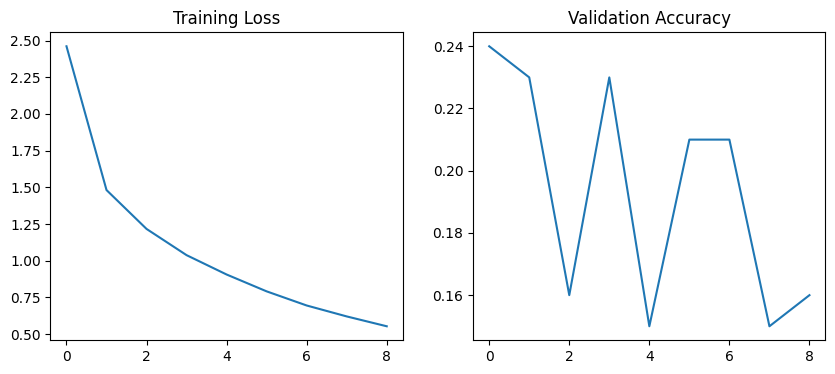

In [11]:
# =====================
# 5. GRAPH
# =====================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")

plt.subplot(1,2,2)
plt.plot(val_accuracies)
plt.title("Validation Accuracy")

plt.show()


In [12]:
torch.save(model, "resnet_model.pth")

In [13]:
model = models.mobilenet_v2(pretrained=True)

for param in model.parameters():
    param.requires_grad = True

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features, 200
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 208MB/s]
